In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Attention Scoring and Masking

In that section we computed attention weights from
distance-based kernels such as the Gaussian. Distances are slightly more
expensive to compute than dot products, and once the softmax
the equation guarantees nonnegative normalized weights, we
are free to pick any *scoring function* $a(\mathbf{q}, \mathbf{k})$ we like.
This section settles the choice used by essentially every modern
architecture—the scaled dot product—and builds the two pieces of machinery
that make it practical: a masked softmax that lets one batched computation
serve sequences of different lengths (and autoregressive models that must
not look ahead), and batched matrix multiplication. We close with the story
of where these ideas came from: the machine translation problem that turned
"learning to align" into the attention mechanism.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import jax
from jax import numpy as jnp
import math

## Dot-Product Attention

Let's review the attention function (without exponentiation) arising from
the Gaussian kernel:

$$
a(\mathbf{q}, \mathbf{k}_i) = -\frac{1}{2} \|\mathbf{q} - \mathbf{k}_i\|^2  = \mathbf{q}^\top \mathbf{k}_i -\frac{1}{2} \|\mathbf{k}_i\|^2  -\frac{1}{2} \|\mathbf{q}\|^2.
$$

First, the final term depends on $\mathbf{q}$ only, so it is identical for
all keys, and the softmax normalization the equation
removes it entirely. Second, if the key norms $\|\mathbf{k}_i\|$ are all
equal, the middle term drops out the same way, and the Gaussian kernel and
the dot product induce identical attention weights. In general the norms are
not equal, and dropping the term is a modeling decision rather than an
approximation: we adopt the dot product $\mathbf{q}^\top \mathbf{k}_i$ as a
compatibility function in its own right — one that learned query and key
representations can shape freely — with the Gaussian expansion surviving as
the exact special case of equal key norms.

One adjustment is still needed, to keep the magnitude of the scores under
control. Assume that all elements of the query $\mathbf{q} \in \mathbb{R}^d$
and the key $\mathbf{k}_i \in \mathbb{R}^d$ are independent random variables
with zero mean and unit variance. The dot product of the two vectors then
has zero mean and variance $d$: the typical score grows like $\sqrt{d}$ for
no reason other than vector length. Rescaling by $1/\sqrt{d}$ keeps the
score variance at $1$ regardless of dimension, and yields the *scaled
dot-product attention* scoring function of the Transformer
[@Vaswani.Shazeer.Parmar.ea.2017]:

$$ a(\mathbf{q}, \mathbf{k}_i) = \mathbf{q}^\top \mathbf{k}_i / \sqrt{d}.$$

The attention weights are obtained, as always, with the softmax:

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}(a(\mathbf{q}, \mathbf{k}_i)) = \frac{\exp(\mathbf{q}^\top \mathbf{k}_i / \sqrt{d})}{\sum_{j=1}^m \exp(\mathbf{q}^\top \mathbf{k}_j / \sqrt{d})}.$$

### Softmax Saturation and the $1/\sqrt{d}$ Factor

Why insist on unit score variance? The softmax saturates: once one score
exceeds the others by a large margin, the winning weight approaches $1$, the
rest approach $0$, and, since the Jacobian of the softmax is

$$
\frac{\partial \boldsymbol{\alpha}}{\partial \mathbf{a}} = \mathrm{diag}(\boldsymbol{\alpha}) - \boldsymbol{\alpha} \boldsymbol{\alpha}^\top,
$$

which tends to the zero matrix as $\boldsymbol{\alpha}$ approaches a one-hot
vector, gradients stop flowing to everything upstream of the scores. The
softmax's gradient never vanishes exactly, as we noted in
that section, but it can come arbitrarily close. Let's
measure both effects rather than take them on faith. We draw random queries
and keys with unit-variance entries, compute attention over $64$ candidate
keys, and record the entropy of the resulting weight distribution as the
dimension $d$ grows, with and without the $1/\sqrt{d}$ factor.

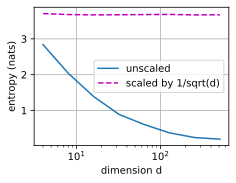

In [2]:
def attention_stats(d, num_keys=64, num_queries=256, scaled=True, seed=0):
    key_q, key_k = jax.random.split(jax.random.key(seed))
    q = jax.random.normal(key_q, (num_queries, d))
    keys = jax.random.normal(key_k, (num_queries, num_keys, d))
    scores = (keys @ q[..., None]).squeeze(-1)
    if scaled:
        scores = scores / math.sqrt(d)
    alpha = jax.nn.softmax(scores, axis=-1)
    entropy = -(alpha * jnp.log(alpha + 1e-12)).sum(-1).mean()
    # Frobenius norm of the softmax Jacobian diag(alpha) - alpha alpha^T
    jac = (alpha[..., None] * jnp.eye(num_keys)
           - alpha[..., :, None] * alpha[..., None, :])
    return float(entropy), float(jnp.sqrt((jac**2).sum((-2, -1))).mean())

ds = [2**k for k in range(2, 10)]
entropies = [[attention_stats(d, scaled=s)[0] for d in ds]
             for s in (False, True)]
d2l.plot(ds, entropies, 'dimension d', 'entropy (nats)',
         legend=['unscaled', 'scaled by 1/sqrt(d)'], xscale='log')

A uniform distribution over $64$ keys has entropy $\ln 64 \approx 4.2$ nats.
The scaled scores hold their entropy essentially constant, at about $3.7$
nats, across two orders of magnitude in $d$: the weight distribution keeps
the same moderate sharpness no matter how wide the vectors are. Without
scaling, the entropy collapses as $d$ grows—below $0.2$ nats by $d = 512$,
meaning the average query puts a weight of more than $0.9$ on a single key
purely because the vectors are long. The gradient tells the same story:

In [3]:
for d in (4, 64, 512):
    _, jac_unscaled = attention_stats(d, scaled=False)
    _, jac_scaled = attention_stats(d, scaled=True)
    print(f'd = {d:3d}: Jacobian norm {jac_unscaled:.3f} (unscaled), '
          f'{jac_scaled:.3f} (scaled)')

d =   4: Jacobian norm 0.258 (unscaled), 0.178 (scaled)
d =  64: Jacobian norm 0.218 (unscaled), 0.184 (scaled)
d = 512: Jacobian norm 0.103 (unscaled), 0.186 (scaled)


With scaling, the Jacobian norm is the same at every dimension. Without it,
the norm decays as the softmax saturates—by $d = 512$ it has fallen to
about half the scaled value and is still shrinking. A model built on
unscaled scores at realistic dimensions would start its life with
near-one-hot attention and barely any gradient with which to fix it. One
division by $\sqrt{d}$ removes the problem, which is why it is part of the
definition the equation rather than a tuning trick.

## Masking

Attention as defined so far attends to *every* key. In practice we routinely
need it not to, for one of two reasons. The first is *padding*: sequences of
different lengths end up in the same minibatch, padded with dummy tokens to
a common length (here shown as `<blank>`):

```
Dive  into  Deep    Learning
Learn to    code    <blank>
Hello world <blank> <blank>
```

Padding tokens carry no meaning, and no query should waste weight on them.
The second reason is *causality*: a language model trained to predict the
next token computes outputs for all positions of a sequence in parallel, and
the query at position $t$ must not see keys at positions beyond $t$—
otherwise the model can copy the very future it is being trained to predict.
Both cases call for the same operation: restrict the attention sum
$\sum_{i=1}^n \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i$ to a valid
prefix $\sum_{i=1}^l \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i$ with
$l \leq n$, where $l$ depends on the sequence (padding) or on the query
position (causality).

### The Masked Softmax Operation

The operation is common enough to have a name, the *masked softmax*, and a
standard implementation trick. Rather than branching on which keys are
valid—conditionals are poison for the heavily optimized batched kernels
that attention runs on—we overwrite the scores of the invalid positions
with a very negative number before the softmax, so that their weights come
out as zero.

The choice of "very negative" deserves care. Older codebases used a literal
constant such as $-10^{6}$. In single precision that works; in the half
precisions that modern training runs in, it does not. The float16 format
tops out near $6.5 \times 10^4$, so $-10^6$ silently overflows, and in
bfloat16 a merely-large constant may fail to fully suppress a weight once
genuine scores are large themselves. Writing literal $-\infty$ masks
exactly, but if every key of some query is masked the softmax returns NaN
and poisons the training run. The dtype-safe idiom, which we adopt, masks
with the most negative *finite* value of the score's dtype
(`torch.finfo(X.dtype).min` and `jnp.finfo(X.dtype).min`, respectively): the
masked weights are exactly zero at any precision, and a fully masked query
degrades to a uniform distribution instead of NaN — though a uniform average
over *invalid* values is still garbage, so callers must guarantee that every
query keeps at least one valid key.

In [4]:
def masked_softmax(X, valid_lens):
    """Perform softmax operation by masking elements on the last axis."""
    # X: 3D tensor, valid_lens: 1D or 2D tensor
    if valid_lens is None:
        return jax.nn.softmax(X, axis=-1)
    shape = X.shape
    if valid_lens.ndim == 1:
        valid_lens = jnp.repeat(valid_lens, shape[1])
    else:
        valid_lens = valid_lens.reshape(-1)
    mask = jnp.arange(shape[-1])[None, :] < valid_lens[:, None]
    # Most negative finite score: exactly zero weight after the softmax,
    # at any precision, without the NaN risk of literal -inf
    X = jnp.where(mask, X.reshape(-1, shape[-1]), jnp.finfo(X.dtype).min)
    return jax.nn.softmax(X.reshape(shape), axis=-1)

To illustrate how this function works, consider a minibatch of two examples
with two queries and four keys each, where the valid lengths are $2$ and
$3$, respectively. All weights beyond the valid length come out as zero,
and each row still sums to $1$:

In [5]:
masked_softmax(jax.random.uniform(jax.random.key(0), (2, 2, 4)),
               jnp.array([2, 3]))

Array([[[0.4922724 , 0.5077276 , 0.        , 0.        ],
        [0.5997409 , 0.40025908, 0.        , 0.        ]],

       [[0.3531402 , 0.19856434, 0.4482954 , 0.        ],
        [0.31042197, 0.2873157 , 0.40226236, 0.        ]]], dtype=float32)

For finer control we can pass a two-dimensional tensor of valid lengths,
one per query:

In [6]:
masked_softmax(jax.random.uniform(jax.random.key(1), (2, 2, 4)),
               jnp.array([[1, 3], [2, 4]]))

Array([[[1.        , 0.        , 0.        , 0.        ],
        [0.35672572, 0.2543091 , 0.38896522, 0.        ]],

       [[0.43679553, 0.5632045 , 0.        , 0.        ],
        [0.2580636 , 0.2509437 , 0.258296  , 0.23269679]]], dtype=float32)

### Causal Masking

Per-query valid lengths are exactly what causality needs: for a sequence of
length $n$, the query at position $t$ may attend to keys $1, \ldots, t$, so
the valid lengths are simply $(1, 2, \ldots, n)$, shared by every sequence
in the batch. The resulting attention pattern is lower triangular:

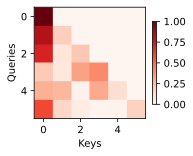

In [7]:
scores = jax.random.normal(jax.random.key(2), (1, 6, 6))
causal_lens = jnp.arange(1, 7)[None, :]  # query t sees keys 1..t
d2l.show_heatmaps(masked_softmax(scores, causal_lens)[None],
                  xlabel='Keys', ylabel='Queries')

On the attention side, this triangular mask is the key difference between a
model that merely reads a sequence and one that can be trained, in parallel
over all positions, to generate it — generation also needs the shifted
next-token objective and a decoding loop. The mask will accompany us through
every decoder in the chapters ahead.

### Composing Masks

`valid_lens` describes prefixes, which cover the two cases above, but the
general interface is a boolean tensor: entry $(i, j)$ says whether query $i$
may attend to key $j$. Every requirement takes this form — padding excludes
keys beyond the sequence length, causality excludes keys beyond the query,
and structural patterns such as the attention windows of
that section exclude by distance — and a key must
survive *all* requirements at once, so masks compose by logical AND.
Broadcasting keeps the bookkeeping cheap: a padding mask has shape
$(\textrm{batch}, 1, \textrm{keys})$, a causal mask
$(1, \textrm{queries}, \textrm{keys})$, and their AND broadcasts to the full
$(\textrm{batch}, \textrm{queries}, \textrm{keys})$ without materializing
either input per example. Applying the composite is the same idiom as
before: overwrite the excluded scores with the dtype's most negative finite
value, then softmax.

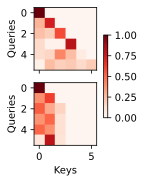

In [8]:
valid_lens, n = jnp.array([6, 3]), 6
j = jnp.arange(n)
padding = (j[None, :] < valid_lens[:, None])[:, None, :]  # (batch, 1, key)
causal = (j[None, :] <= j[:, None])[None, :, :]         # (1, query, key)
mask = padding & causal                                 # (batch, query, key)
scores = jax.random.normal(jax.random.key(0), (2, n, n))
weights = jax.nn.softmax(
    jnp.where(mask, scores, jnp.finfo(scores.dtype).min), axis=-1)
d2l.show_heatmaps(weights[:, None], xlabel='Keys', ylabel='Queries')

The first sequence shows the plain causal triangle; the second is cut off
at its valid length of $3$, the intersection of both constraints. Composition
sharpens the fully-masked hazard flagged above: masks that are harmless
alone can leave some query with an empty intersection, so the guarantee of
at least one valid key per query must hold for the *composite*. The same
machinery handles *packed sequences* — several documents concatenated into
one training row — by ANDing the causal mask with a block-diagonal mask
that keeps each document from attending into its neighbors.

## Batched Attention

### Batch Matrix Multiplication

Attention is computed on minibatches of queries, keys, and values, so we
need to multiply batches of matrices by one another. Assume that

$$
\mathbf{Q} = [\mathbf{Q}_1, \mathbf{Q}_2, \ldots, \mathbf{Q}_n]  \in \mathbb{R}^{n \times a \times b}, \qquad
\mathbf{K} = [\mathbf{K}_1, \mathbf{K}_2, \ldots, \mathbf{K}_n]  \in \mathbb{R}^{n \times b \times c}.
$$

Then the batch matrix multiplication (BMM) computes one matrix product per
batch element,

$$\textrm{BMM}(\mathbf{Q}, \mathbf{K}) = [\mathbf{Q}_1 \mathbf{K}_1, \mathbf{Q}_2 \mathbf{K}_2, \ldots, \mathbf{Q}_n \mathbf{K}_n] \in \mathbb{R}^{n \times a \times c}.$$

Let's see this in action in a deep learning framework:

In [9]:
Q = jnp.ones((2, 3, 4))
K = jnp.ones((2, 4, 6))
d2l.check_shape(jax.lax.batch_matmul(Q, K), (2, 3, 6))

### The DotProductAttention Class

Now we can state scaled dot-product attention in the form in which it is
actually computed. For $n$ queries and $m$ key--value pairs, with queries
and keys of length $d$ and values of length $v$, stack the queries into
$\mathbf{Q} \in \mathbb{R}^{n \times d}$, the keys into $\mathbf{K} \in
\mathbb{R}^{m \times d}$, and the values into $\mathbf{V} \in
\mathbb{R}^{m \times v}$. Then the entire attention computation is two
matrix products and a softmax:

$$ \mathrm{softmax}\left(\frac{\mathbf{Q} \mathbf{K}^\top }{\sqrt{d}}\right) \mathbf{V} \in \mathbb{R}^{n \times v}.$$

Requiring queries and keys to share the length $d$ is no real restriction:
a learned matrix $\mathbf{M}$ turns $\mathbf{q}^\top \mathbf{k}$ into
$\mathbf{q}^\top \mathbf{M} \mathbf{k}$ and translates between spaces of
different dimension (an exercise below). Applied to a minibatch,
the equation uses the batch matrix multiplication of
the equation twice. The implementation applies dropout to
the attention weights as regularization, and stores the weights for
visualization:

In [10]:
class DotProductAttention(nnx.Module):
    """Scaled dot product attention."""
    def __init__(self, dropout, rngs=None):
        rngs = nnx.Rngs(dropout=0) if rngs is None else rngs
        self.dropout = nnx.Dropout(dropout, rngs=rngs)

    # Shape of queries: (batch_size, no. of queries, d)
    # Shape of keys: (batch_size, no. of key-value pairs, d)
    # Shape of values: (batch_size, no. of key-value pairs, value dimension)
    # Shape of valid_lens: (batch_size,) or (batch_size, no. of queries)
    def __call__(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # Swap the last two dimensions of keys with keys.swapaxes(1, 2)
        scores = queries@(keys.swapaxes(1, 2)) / math.sqrt(d)
        attention_weights = masked_softmax(scores, valid_lens)
        # NNX idiom: return (output, weights); PyTorch stores weights on self
        return self.dropout(attention_weights) @ values, attention_weights

To see the class at work we use a minibatch of size $2$, with $10$ keys and
values of dimension $4$, a single $2$-dimensional query per example, and
valid lengths of $2$ and $6$. The output is one $4$-dimensional row per
query:

In [11]:
queries = jax.random.normal(jax.random.key(0), (2, 1, 2))
keys = jax.random.normal(jax.random.key(1), (2, 10, 2))
values = jax.random.normal(jax.random.key(2), (2, 10, 4))
valid_lens = jnp.array([2, 6])

attention = DotProductAttention(dropout=0.5)
output, attention_weights = nnx.view(
    attention, deterministic=True)(queries, keys, values, valid_lens)
d2l.check_shape(output, (2, 1, 4))

The stored attention weights confirm that the mask did its job: weights
vanish beyond the second and sixth key, respectively.

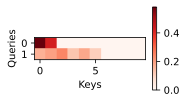

In [12]:
d2l.show_heatmaps(attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

## From Alignment to Attention

Where did all of this come from? Not from databases, but from machine
translation. Around 2014, the leading neural approach encoded a source
sentence with an RNN into a single fixed-size state vector and decoded the
translation from that vector with a second RNN (we build such
encoder--decoder models in full in that section). The design has
the flaw this chapter opened with: one fixed-size vector must carry an
entire sentence, and for long sentences it cannot. Translation quality
degraded visibly with sentence length. @Graves.2013 had faced a
version of this problem when generating handwriting from text, and solved
it with a differentiable model that *aligned* each output pen stroke with a
position in the source text—though with the constraint that the alignment
could only move forward, an assumption borrowed from decoding in speech
recognition [@rabiner1993fundamentals].

@Bahdanau.Cho.Bengio.2014 removed the constraint. Their translation
model kept the two RNNs but gave the decoder a new capability at every
step: use the current decoder state as a *query* against all encoder
states, which serve as keys and values, and feed the resulting weighted
summary—a fresh one per output token—into the next prediction. The paper's
title called the idea "jointly learning to align and translate", and the
learned weights behaved exactly like the soft alignments of classical
statistical translation: mostly monotone along the diagonal, with clean
departures where the two languages order words differently, as sketched in
the figure. Nothing forced the model to align; the behavior
emerged from training. This is the attention mechanism of
the equation in its original habitat, and its impact
reached far beyond translation.

![Soft alignment between an English sentence and its French translation, in the style of a learned attention map (darker cells indicate larger weight; schematic). The alignment is mostly monotone, but "black cat" maps to "chat noir" with the order reversed, and both "était" and "assis" draw on "sat".](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-attention-alignment.svg)

One detail differed from the scoring function we settled on above. The
decoder state and the encoder states were vectors of different sizes, so
instead of a dot product, @Bahdanau.Cho.Bengio.2014 scored with a
small one-hidden-layer MLP, now known as *additive attention*:

$$a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \tanh(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k}) \in \mathbb{R},$$

where $\mathbf{W}_q \in \mathbb{R}^{h \times q}$, $\mathbf{W}_k \in
\mathbb{R}^{h \times k}$, and $\mathbf{w}_v \in \mathbb{R}^{h}$ are learned.
The two projections embed queries and keys into a shared $h$-dimensional
space, and $\mathbf{w}_v$ reads a score off the sum. It takes only a few
lines to compute—here scoring three $20$-dimensional queries against six
$2$-dimensional keys, dimensions no dot product could pair up:

In [13]:
key_q, key_k, k1, k2, k3 = jax.random.split(jax.random.key(0), 5)
queries = jax.random.normal(key_q, (3, 20))
keys = jax.random.normal(key_k, (6, 2))
num_hiddens = 8
W_q = jax.random.normal(k1, (num_hiddens, 20)) / math.sqrt(20)
W_k = jax.random.normal(k2, (num_hiddens, 2)) / math.sqrt(2)
w_v = jax.random.normal(k3, (num_hiddens,)) / math.sqrt(num_hiddens)
features = jnp.tanh((queries @ W_q.T)[:, None, :]
                    + (keys @ W_k.T)[None, :, :])
scores = features @ w_v
d2l.check_shape(scores, (3, 6))
jax.nn.softmax(scores, axis=-1)

Array([[0.13390937, 0.3772766 , 0.17127123, 0.1027277 , 0.06276076,
        0.15205443],
       [0.19218282, 0.31524566, 0.14511336, 0.08953383, 0.07662669,
        0.18129766],
       [0.15669951, 0.3378386 , 0.15281527, 0.11713327, 0.09428051,
        0.1412329 ]], dtype=float32)

Additive attention held its own for a few years, but the outcome was
decided by hardware: a dot product between all queries and all keys is a
single matrix multiplication, the one operation accelerators are built
around, while the additive score requires materializing an
$n \times m \times h$ tensor of hidden activations. When a learned metric
is wanted, projecting queries and keys with learned matrices *before* a dot
product achieves it at matmul speed—which is precisely the form attention
takes inside the Transformer, whose authors then discarded the RNN
scaffolding altogether and kept attention as the only mechanism relating
sequence positions [@Vaswani.Shazeer.Parmar.ea.2017]. The next
sections follow that road: first attention with multiple heads, then what
replaces the RNN's notion of position.

## Summary

Softmax normalization turns any scoring function into valid attention
weights, and the scoring function of choice is the scaled dot product
the equation: it is a single batched matrix
multiplication, and the $1/\sqrt{d}$ factor holds the score variance at $1$
so that the softmax neither saturates nor starves its own gradient as the
dimension grows—an effect we measured directly. Masking makes the same
batched computation respect variable sequence lengths and causal
structure: overwrite invalid scores with the most negative finite value of
the dtype (not a hard-coded constant, which breaks in half precision)
before the softmax; arbitrary boolean requirements — padding, causality,
structure — compose into one mask by logical AND. `DotProductAttention` packages scoring, masking,
dropout on the weights, and value pooling in a dozen lines that the rest of
this book reuses. Additive attention, the original scoring function of the
translation models that started the field, survives as history and as a
reminder that attention weights are learned soft alignments.

## Exercises

1. Implement distance-based attention by modifying the
   `DotProductAttention` code. You only need the squared norms of the keys
   $\|\mathbf{k}_i\|^2$ for an efficient implementation.
1. Modify dot-product attention to allow for queries and keys of different
   dimensionalities by employing a matrix $\mathbf{M}$ to adjust dimensions,
   scoring with $\mathbf{q}^\top \mathbf{M} \mathbf{k}$.
1. How does the computational cost of the equation scale with
   the dimensionality of keys, queries, and values, and with their number?
   What about the memory bandwidth requirements?
1. Derive the softmax Jacobian $\mathrm{diag}(\boldsymbol{\alpha}) -
   \boldsymbol{\alpha}\boldsymbol{\alpha}^\top$ and verify it numerically
   against automatic differentiation on a random score vector. Compute its
   Frobenius norm when $\boldsymbol{\alpha}$ is one-hot and when it is
   uniform over $m$ keys. Which regime does the saturation experiment
   approach as $d$ grows without scaling?
1. What does `masked_softmax` return for a query whose valid length is $0$?
   Compare the behavior of masking with the most negative finite value
   against masking with literal $-\infty$. In what situations can a fully
   masked query arise in practice, and what would you do about it?
1. Count the parameters and floating-point operations needed to score $n$
   queries against $m$ keys with additive attention (hidden size $h$) and
   with scaled dot-product attention (shared dimension $d$). Implement a
   batched version of the additive score and time both variants for
   $d = h = 64$ and $d = h = 256$. Which is faster on your hardware, and
   why?